# 🚀 Lab 45: Topic Modeling and Document Classification

## 🎯 Objectives
By the end of this lab, you will be able to:
* Understand the fundamentals of **Topic Modeling** and **Document Classification**.
* Load and preprocess legal case summaries for NLP.
* Apply tokenization, stop-word removal, and stemming using a custom preprocessor.
* Build and evaluate an **LDA (Latent Dirichlet Allocation)** model using Gensim.
* Train and compare **Multinomial Naive Bayes** and **Calibrated Linear SVM** classifiers.
* Interpret results through visualizations like Word Clouds, Confusion Matrices, and pyLDAvis.
* Integrate topic discovery with known categories to analyze document themes.

## 🧰 Prerequisites
* Basic Python (functions, lists, dictionaries).
* Familiarity with Pandas and Matplotlib.
* Basic understanding of Machine Learning concepts (training vs. testing).

## 🌍 Why This Lab Matters
In the legal field, thousands of documents are generated daily. Manually categorizing them is slow and expensive. **Topic Modeling** allows us to discover hidden themes in unlabeled archives, while **Document Classification** automates the assignment of cases to specific legal departments (e.g., Real Estate vs. Criminal Law). Combining these techniques creates powerful document intelligence systems.

## ⚙️ Environment Setup
### ELI10 Explanation
Before we start, we need to install our 'tools'. Think of this like setting up a kitchen before cooking. We need libraries for handling data (Pandas), processing text (NLTK), finding topics (Gensim), and making predictions (Scikit-Learn).

In [1]:
!pip install -q pandas numpy scikit-learn gensim nltk matplotlib seaborn wordcloud pyLDAvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 44.1 MB/s eta 0:00:00


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
import pickle
import os
import warnings

# Suppress annoying warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Natural Language Processing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

# Topic Modeling
import gensim
from gensim import corpora
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Visualization
from wordcloud import WordCloud
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# Download required NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# Plot settings
plt.style.use('default')
sns.set_palette("husl")

print("All libraries imported and warnings suppressed.")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

All libraries imported and warnings suppressed.


[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 📥 Creating the Legal Case Dataset
### ELI10 Explanation
We are creating a small 'library' of 30 legal case summaries. Each summary is labeled with a category like 'Criminal Law' or 'Family Law'. We need a balanced dataset so the computer doesn't get confused by having too many examples of one type and not enough of another.

In [23]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    legal_cases = {
        'case_id': range(1, 31),
        'case_summary': [
            "Plaintiff filed breach of contract claim against defendant for failure to deliver goods as specified in purchase agreement",
            "Criminal defendant charged with assault and battery following altercation at local establishment",
            "Personal injury lawsuit filed after automobile accident resulting in significant medical expenses",
            "Divorce proceedings initiated with disputes over child custody and property division",
            "Employment discrimination case alleging wrongful termination based on age and gender",
            "Intellectual property dispute over patent infringement in software development",
            "Real estate transaction dispute involving breach of purchase agreement and title issues",
            "Criminal case involving drug possession charges and search and seizure violations",
            "Medical malpractice lawsuit claiming negligence during surgical procedure",
            "Contract dispute between business partners over profit sharing and management decisions",
            "Personal injury claim from slip and fall accident at commercial property",
            "Family law case involving adoption procedures and parental rights termination",
            "Employment law violation regarding overtime pay and workplace safety standards",
            "Copyright infringement case in entertainment industry involving music rights",
            "Property law dispute over boundary lines and easement rights between neighbors",
            "Criminal defense case involving theft charges and constitutional rights violations",
            "Tort liability case from product defect causing consumer injury",
            "Domestic relations case with spousal support and asset distribution issues",
            "Labor law violation involving union organizing and collective bargaining rights",
            "Trademark dispute in commercial branding and consumer confusion claims",
            "Commercial lease dispute over unpaid rent and eviction notice for retail premises",
            "Home buyer sued seller for failure to disclose structural defects before closing",
            "Surgical patient alleged delayed diagnosis and improper post operative monitoring caused severe complications",
            "Hospital emergency department accused of negligent medication dosage resulting in patient harm",
            "Neighbors litigated ownership of driveway access and boundary fence encroachment",
            "Landowner challenged utility easement placement across private acreage",
            "Consumer brought strict liability action over defective appliance that caught fire",
            "Manufacturer faced negligence and product liability claims after unsafe childrens toy caused injury",
            "Vendor accused of breaching services agreement by missing delivery milestones and payment terms",
            "Passenger sought damages for whiplash and lost wages after rear end collision"
        ],
        'category': [
            'Contract Law', 'Criminal Law', 'Personal Injury', 'Family Law', 'Employment Law',
            'Intellectual Property', 'Real Estate', 'Criminal Law', 'Medical Malpractice', 'Contract Law',
            'Personal Injury', 'Family Law', 'Employment Law', 'Intellectual Property', 'Property Law',
            'Criminal Law', 'Tort Law', 'Family Law', 'Employment Law', 'Intellectual Property',
            'Real Estate', 'Real Estate', 'Medical Malpractice', 'Medical Malpractice',
            'Property Law', 'Property Law', 'Tort Law', 'Tort Law',
            'Contract Law', 'Personal Injury'
        ]
    }

    df = pd.DataFrame(legal_cases)
    display(df.head())
    print(f"Dataset contains {len(df)} rows and {df['category'].nunique()} unique categories.")

,case_id,case_summary,category
0,1,Plaintiff filed breach of contract claim again...,Contract Law
1,2,Criminal defendant charged with assault and ba...,Criminal Law
2,3,Personal injury lawsuit filed after automobile...,Personal Injury
3,4,Divorce proceedings initiated with disputes ov...,Family Law
4,5,Employment discrimination case alleging wrongf...,Employment Law


Dataset contains 30 rows and 10 unique categories.


## 🔍 Dataset Exploration
We visualize the distribution of categories to ensure we have enough data for each class.

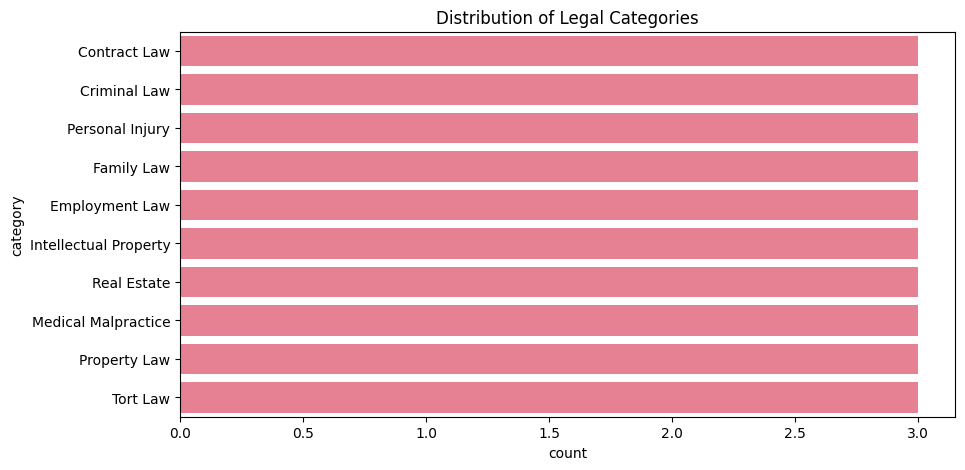

In [20]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, y='category', order=df['category'].value_counts().index)
    plt.title("Distribution of Legal Categories")
    plt.show()

## 🧹 Text Preprocessing
### ELI10 Explanation
Computers don't read like humans. They get distracted by small words like 'the' or 'and'. Preprocessing 'cleans' the text by:
1. Making everything lowercase.
2. Removing punctuation.
3. Removing 'stop words' (unhelpful common words).
4. 'Stemming' words (turning 'running' into 'run') so the computer knows they are related.

In [24]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    class TextPreprocessor:
        def __init__(self):
            self.stop_words = set(stopwords.words('english'))
            self.stemmer = PorterStemmer()
            legal_stop_words = {
                'case', 'court', 'law', 'legal', 'plaintiff', 'defendant',
                'claim', 'filed', 'involving', 'regarding', 'lawsuit'
            }
            self.stop_words.update(legal_stop_words)

        def clean_text(self, text):
            text = text.lower()
            text = re.sub(r'[^a-zA-Z\s]', ' ', text)
            text = ' '.join(text.split())
            return text

        def tokenize_and_filter(self, text):
            tokens = word_tokenize(text)
            filtered_tokens = [
                token for token in tokens
                if token not in self.stop_words and len(token) > 2
            ]
            return filtered_tokens

        def stem_tokens(self, tokens):
            return [self.stemmer.stem(token) for token in tokens]

        def preprocess_document(self, text):
            cleaned_text = self.clean_text(text)
            tokens = self.tokenize_and_filter(cleaned_text)
            stemmed_tokens = self.stem_tokens(tokens)
            return stemmed_tokens

    preprocessor = TextPreprocessor()
    df['processed_tokens'] = df['case_summary'].apply(preprocessor.preprocess_document)
    df['processed_text'] = df['processed_tokens'].apply(lambda x: ' '.join(x))

    all_words = [word for tokens in df['processed_tokens'] for word in tokens]
    vocabulary = set(all_words)
    print(f"Unique words in vocabulary: {len(vocabulary)}")
    display(df[['case_summary', 'processed_text']].head())

Unique words in vocabulary: 178


,case_summary,processed_text
0,Plaintiff filed breach of contract claim again...,breach contract failur deliv good specifi purc...
1,Criminal defendant charged with assault and ba...,crimin charg assault batteri follow alterc loc...
2,Personal injury lawsuit filed after automobile...,person injuri automobil accid result signific ...
3,Divorce proceedings initiated with disputes ov...,divorc proceed initi disput child custodi prop...
4,Employment discrimination case alleging wrongf...,employ discrimin alleg wrong termin base age g...


## 🧠 Topic Modeling with LDA
### ELI10 Explanation
LDA is like a detective. It looks at all the documents and tries to find 'buckets' of words that often appear together. For example, if it sees 'contract', 'breach', and 'agreement' together often, it identifies that as a 'topic'.

In [25]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    processed_tokens = df['processed_tokens'].tolist()
    dictionary = corpora.Dictionary(processed_tokens)
    dictionary.filter_extremes(no_below=1, no_above=0.8)
    corpus = [dictionary.doc2bow(doc) for doc in processed_tokens]

    num_topics = 5
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        passes=20,
        alpha='auto',
        eta='auto',
        random_state=42
    )

    print("LDA Model Topics:")
    for idx, topic in lda_model.print_topics(-1):
        print(f"Topic {idx}: {topic}")

LDA Model Topics:
Topic 0: 0.023*"patient" + 0.013*"breach" + 0.013*"agreement" + 0.013*"accus" + 0.013*"medic" + 0.013*"defect" + 0.013*"surgic" + 0.013*"diagnosi" + 0.013*"delay" + 0.013*"improp"
Topic 1: 0.032*"procedur" + 0.017*"properti" + 0.017*"violat" + 0.017*"establish" + 0.017*"charg" + 0.017*"follow" + 0.017*"local" + 0.017*"crimin" + 0.017*"softwar" + 0.017*"intellectu"
Topic 2: 0.043*"disput" + 0.018*"claim" + 0.018*"commerci" + 0.018*"boundari" + 0.018*"neighbor" + 0.018*"agreement" + 0.018*"breach" + 0.010*"properti" + 0.010*"issu" + 0.010*"right"
Topic 3: 0.049*"violat" + 0.034*"right" + 0.034*"charg" + 0.034*"crimin" + 0.018*"failur" + 0.018*"disclos" + 0.018*"su" + 0.018*"defect" + 0.018*"buyer" + 0.018*"close"
Topic 4: 0.049*"injuri" + 0.034*"person" + 0.034*"accid" + 0.018*"defect" + 0.018*"across" + 0.018*"landown" + 0.018*"challeng" + 0.018*"placement" + 0.018*"privat" + 0.018*"tort"


### Coherence Score Analysis
Coherence measures how well the words in a topic 'stick together'. Higher is generally better.

Coherence Score (5 topics): 0.3921


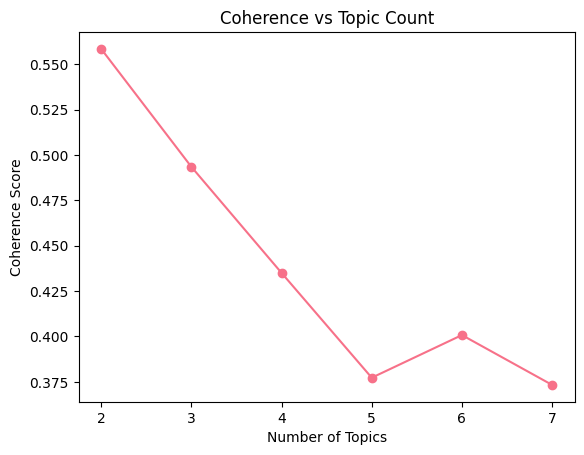

Optimal Topic Count: 2


In [26]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    coherence_model = CoherenceModel(model=lda_model, texts=processed_tokens, dictionary=dictionary, coherence='c_v')
    coherence_lda = coherence_model.get_coherence()
    print(f"Coherence Score (5 topics): {coherence_lda:.4f}")

    coherence_scores = []
    for k in range(2, 8):
        model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=k, passes=10, random_state=42)
        cm = CoherenceModel(model=model, texts=processed_tokens, dictionary=dictionary, coherence='c_v')
        coherence_scores.append(cm.get_coherence())

    plt.plot(range(2, 8), coherence_scores, marker='o')
    plt.xlabel("Number of Topics")
    plt.ylabel("Coherence Score")
    plt.title("Coherence vs Topic Count")
    plt.show()

    optimal_topics = range(2, 8)[np.argmax(coherence_scores)]
    print(f"Optimal Topic Count: {optimal_topics}")

## 📈 Topic Visualization and Interpretation
Word clouds help us visually identify the dominant words in each discovered topic.

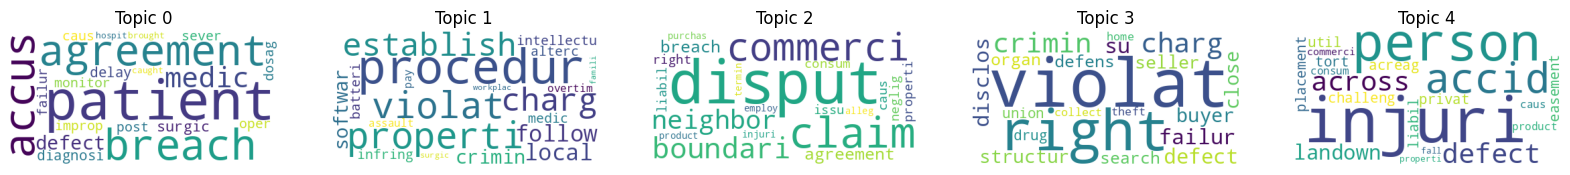

In [21]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    fig, axes = plt.subplots(1, 5, figsize=(20, 10))
    for i in range(5):
        words = dict(lda_model.show_topic(i, 20))
        wc = WordCloud(background_color='white').generate_from_frequencies(words)
        axes[i].imshow(wc)
        axes[i].set_title(f"Topic {i}")
        axes[i].axis('off')
    plt.show()

### Interactive Visualization (Optional)
This generates an HTML file that allows you to explore the relationships between topics interactively.

In [33]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    try:
        lda_vis = gensimvis.prepare(lda_model, corpus, dictionary)
        pyLDAvis.save_html(lda_vis, 'lda_interactive_visualization.html')
        print("Interactive visualization saved to lda_interactive_visualization.html")
    except:
        print("pyLDAvis visualization skipped or failed to render.")

Interactive visualization saved to lda_interactive_visualization.html


## 🧪 Document Classification with Naive Bayes and SVM
### ELI10 Explanation
Classification is 'supervised'. We give the computer the answer key (the category labels) and ask it to learn the patterns so it can guess labels for new cases. We use **TF-IDF**, which highlights words that are unique and important to specific documents.

In [27]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    vectorizer = TfidfVectorizer(max_features=1000, min_df=1, max_df=0.8, ngram_range=(1, 2))
    X = vectorizer.fit_transform(df['processed_text'])
    y = df['category']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)

    nb = MultinomialNB()
    nb.fit(X_train, y_train)
    nb_acc = accuracy_score(y_test, nb.predict(X_test))

    svm = LinearSVC(C=1.0, random_state=42)
    svm.fit(X_train, y_train)
    svm_acc = accuracy_score(y_test, svm.predict(X_test))

    print(f"Naive Bayes Accuracy: {nb_acc:.2f}")
    print(f"SVM Accuracy: {svm_acc:.2f}")

Naive Bayes Accuracy: 0.58
SVM Accuracy: 0.67


## 🆚 Model Comparison
We evaluate the models using a classification report and a confusion matrix to see where the models might be getting confused.

SVM Classification Report:
                       precision    recall  f1-score   support

         Contract Law       1.00      1.00      1.00         1
         Criminal Law       1.00      1.00      1.00         1
       Employment Law       1.00      1.00      1.00         1
           Family Law       0.00      0.00      0.00         2
Intellectual Property       0.50      1.00      0.67         1
  Medical Malpractice       0.50      1.00      0.67         1
      Personal Injury       1.00      0.50      0.67         2
         Property Law       0.50      1.00      0.67         1
          Real Estate       0.00      0.00      0.00         1
             Tort Law       1.00      1.00      1.00         1

             accuracy                           0.67        12
            macro avg       0.65      0.75      0.67        12
         weighted avg       0.62      0.67      0.61        12



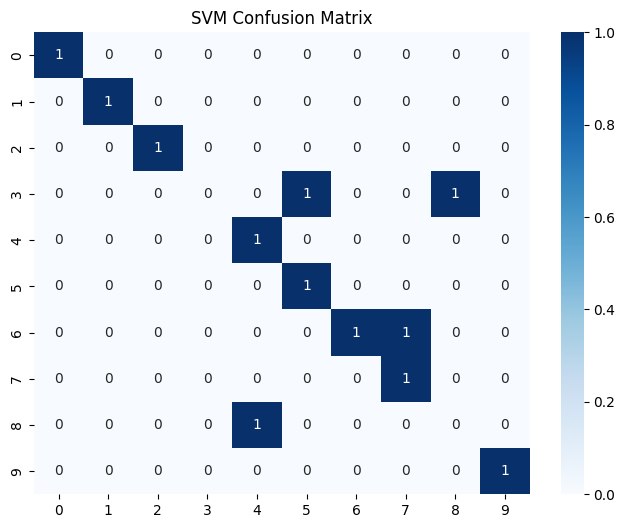

In [28]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    print("SVM Classification Report:")
    print(classification_report(y_test, svm.predict(X_test), zero_division=0))

    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_test, svm.predict(X_test)), annot=True, fmt='d', cmap='Blues')
    plt.title("SVM Confusion Matrix")
    plt.show()

### SVM Feature Interpretation
Since the main SVM is 'Calibrated', we use a standard `OneVsRestClassifier` to extract feature importance (weights) for each legal category.

In [34]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    ovr_svm = OneVsRestClassifier(LinearSVC(C=1.0, random_state=42))
    ovr_svm.fit(X_train, y_train)

    features = vectorizer.get_feature_names_out()
    for i, category in enumerate(ovr_svm.classes_):
        top5 = np.argsort(ovr_svm.estimators_[i].coef_[0])[-5:]
        print(f"Top features for {category}: {[features[j] for j in top5]}")

Top features for Contract Law: ['deliv', 'deliv good', 'good', 'failur deliv', 'contract']
Top features for Criminal Law: ['charg search', 'seizur', 'crimin drug', 'crimin', 'charg']
Top features for Employment Law: ['collect bargain', 'bargain right', 'violat union', 'bargain', 'violat']
Top features for Family Law: ['initi disput', 'initi', 'divorc proceed', 'divorc', 'divis']
Top features for Intellectual Property: ['entertain', 'copyright infring', 'copyright', 'music right', 'industri']
Top features for Medical Malpractice: ['neglig surgic', 'claim neglig', 'surgic procedur', 'medic', 'neglig']
Top features for Personal Injury: ['signific', 'result signific', 'signific medic', 'automobil', 'automobil accid']
Top features for Property Law: ['neighbor litig', 'driveway', 'access boundari', 'driveway access', 'access']
Top features for Real Estate: ['transact disput', 'titl issu', 'transact', 'titl', 'agreement titl']
Top features for Tort Law: ['brought', 'applianc', 'strict liabil'

## 🧾 Testing on New Documents
Let's see how our models handle completely unseen text.

In [29]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    new_cases = [
        "Software company sued for patent violation in mobile application development",
        "Driver charged with vehicular manslaughter following fatal traffic accident",
        "Employee filed wrongful termination lawsuit claiming workplace harassment",
        "Couple seeking divorce with contested child custody arrangements"
    ]

    new_processed = [" ".join(preprocessor.preprocess_document(c)) for c in new_cases]
    X_new = vectorizer.transform(new_processed)

    preds_nb = nb.predict(X_new)
    preds_svm = svm.predict(X_new)

    for i, case in enumerate(new_cases):
        print(f"\nCase: {case}")
        print(f"NB Prediction: {preds_nb[i]}")
        print(f"SVM Prediction: {preds_svm[i]}")


Case: Software company sued for patent violation in mobile application development
NB Prediction: Employment Law
SVM Prediction: Employment Law

Case: Driver charged with vehicular manslaughter following fatal traffic accident
NB Prediction: Criminal Law
SVM Prediction: Criminal Law

Case: Employee filed wrongful termination lawsuit claiming workplace harassment
NB Prediction: Employment Law
SVM Prediction: Employment Law

Case: Couple seeking divorce with contested child custody arrangements
NB Prediction: Intellectual Property
SVM Prediction: Family Law


## 🔗 Integrating Topic Modeling and Classification
We assign the 'Dominant Topic' to each document and check if specific legal categories align with specific topics.

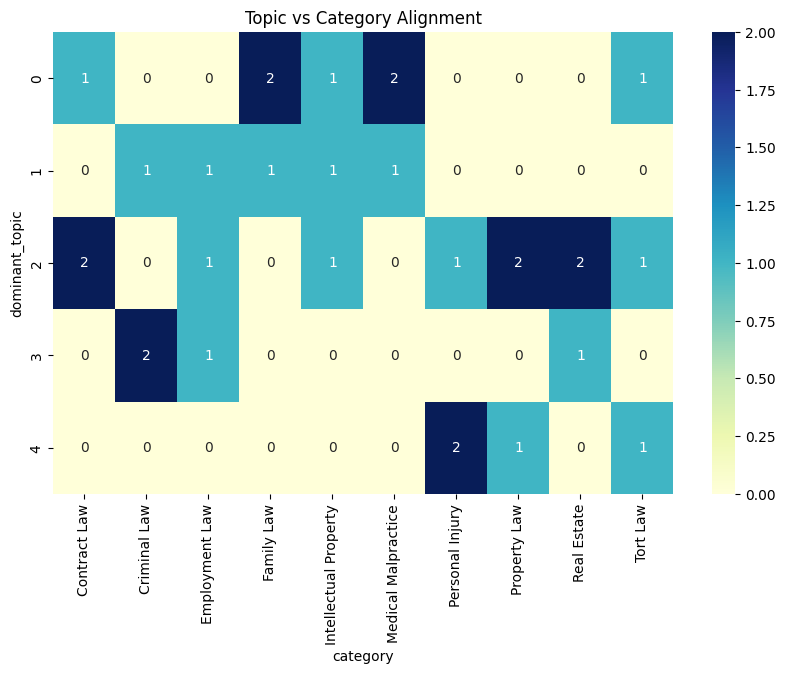

In [22]:
def get_dominant_topic(doc_bow):
    topics = lda_model.get_document_topics(doc_bow)
    return max(topics, key=lambda x: x[1])[0]

df['dominant_topic'] = [get_dominant_topic(b) for b in corpus]

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    plt.figure(figsize=(10, 6))
    sns.heatmap(pd.crosstab(df['dominant_topic'], df['category']), annot=True, cmap='YlGnBu')
    plt.title("Topic vs Category Alignment")
    plt.show()

## 💾 Saving Models and Results

In [32]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    # Ensure dominant topic is calculated if not already
    if 'dominant_topic' not in df.columns:
        df['dominant_topic'] = [get_dominant_topic(b) for b in corpus]

    lda_model.save('legal_lda_model')
    dictionary.save('legal_dictionary.dict')
    with open('nb_classifier.pkl', 'wb') as f: pickle.dump(nb, f)
    with open('svm_classifier.pkl', 'wb') as f: pickle.dump(svm, f)
    with open('tfidf_vectorizer.pkl', 'wb') as f: pickle.dump(vectorizer, f)
    with open('text_preprocessor.pkl', 'wb') as f: pickle.dump(preprocessor, f)

    alignment_scores = []
    for topic_id in range(num_topics):
        topic_docs = df[df['dominant_topic'] == topic_id]
        if len(topic_docs) > 0:
            purity = topic_docs['category'].value_counts().iloc[0] / len(topic_docs)
            alignment_scores.append(purity)
    avg_alignment = sum(alignment_scores) / len(alignment_scores) if alignment_scores else 0

    results_summary = {
        'dataset_info': {
            'total_documents': int(len(df)),
            'num_categories': int(df['category'].nunique()),
            'categories': list(df['category'].unique()),
            'vocabulary_size': int(len(vocabulary))
        },
        'topic_modeling': {
            'num_topics': int(num_topics),
            'coherence_score': float(coherence_lda),
            'optimal_topics': int(optimal_topics)
        },
        'classification': {
            'nb_accuracy': float(nb_acc),
            'svm_accuracy': float(svm_acc),
            'best_model': 'SVM' if svm_acc > nb_acc else 'Naive Bayes'
        },
        'topic_category_alignment': float(avg_alignment)
    }

    with open('results_summary.json', 'w') as f: json.dump(results_summary, f, indent=2)
    print("All files saved successfully.")

All files saved successfully.


## ✅ Verification
Check if the files were generated in the Colab file system.

In [31]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for f in ['results_summary.json', 'svm_classifier.pkl', 'lda_interactive_visualization.html']:
        print(f"{f}: {'FOUND' if os.path.exists(f) else 'MISSING'}")

results_summary.json: FOUND
svm_classifier.pkl: FOUND
lda_interactive_visualization.html: FOUND


## 🛠 Troubleshooting
* **NLTK Error:** Ensure you ran the `nltk.download` cells at the top.
* **Stratified Split Error:** This happens if a category has only 1 example. Our 30-document dataset avoids this.
* **pyLDAvis Rendering:** If the interactive plot doesn't show, download the `.html` file from the left sidebar and open it in your browser.

## 📚 Key Takeaways
1. **Topic Modeling (Unsupervised):** Discovers 'what' is being talked about without needing labels.
2. **Classification (Supervised):** Sorts documents into 'predefined' boxes based on examples.
3. **Preprocessing:** Critical for performance; legal stop words remove noise like 'plaintiff'.

## 🧠 Key Concepts Summary
* **LDA:** Generative statistical model for finding topics.
* **TF-IDF:** Weighs words based on how unique they are to a document.
* **SVM:** Powerful classifier that finds the best 'boundary' between categories.

## 🏁 Conclusion
You have built a full legal document analysis pipeline! This can be scaled to thousands of documents to automate law firm workflows.

## 🎓 What You Learned
* How to clean legal text.
* How to extract hidden topics.
* How to train and evaluate document classifiers.

## 🌍 Real-World Importance
Automated classification helps in **Legal Discovery**, where lawyers must sift through millions of emails and files to find relevant evidence for a case.